# Activity Classification with Multi-Sensor Fusion
Classes:

0 : Rest 

1 : Physical Activity

2 : Intense Physical Activity

Main dataset: PAMAP2

Real features: IMU + Heart Rate

Synthetic features (temporary): EMG + Temperature

1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

2. Config cell

In [2]:
WINDOW_SIZE = 200
STEP_SIZE = 100
RANDOM_STATE = 42

LABEL_NAMES = {
    0: "rest",
    1: "moderate",
    2: "intense"
}

3. Load PAMAP2 data

In [3]:
columns = [
    "timestamp",
    "activity_id",
    "heart_rate",

    # hand
    "temp_hand",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand"
]

df = pd.read_csv("../data/raw/PAMAP2_Dataset/Protocol/subject101.dat", sep=" ", header=None)

# keep only needed columns
df = df.iloc[:, :len(columns)]
df.columns = columns

df.head()

,timestamp,activity_id,heart_rate,temp_hand,acc_x_hand,acc_y_hand,acc_z_hand,gyro_x_hand,gyro_y_hand,gyro_z_hand
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295


4. Map PAMAP2 activities to the 3 classes

In [4]:
pamap2_activity_map = {
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "nordic_walking",
    12: "ascending_stairs",
    13: "descending_stairs",
    16: "vacuum_cleaning",
    17: "ironing",
    24: "rope_jumping"
}

three_class_map = {
    "lying": 0,
    "sitting": 0,

    "standing": 1,
    "walking": 1,
    "nordic_walking": 1,
    "ascending_stairs": 1,
    "descending_stairs": 1,
    "vacuum_cleaning": 1,
    "ironing": 1,

    "running": 2,
    "cycling": 2,
    "rope_jumping": 2
}

df["activity_name"] = df["activity_id"].map(pamap2_activity_map)
df = df[df["activity_name"].notna()].copy()
df["label"] = df["activity_name"].map(three_class_map)

df[["activity_id", "activity_name", "label"]].head()

,activity_id,activity_name,label
2928,1,lying,0
2929,1,lying,0
2930,1,lying,0
2931,1,lying,0
2932,1,lying,0


5. Quick label distribution check

In [5]:
print(df["label"].value_counts().sort_index())
print(df["activity_name"].value_counts())

label
0     50667
1    141538
2     57752
Name: count, dtype: int64
activity_name
lying                27187
cycling              23575
ironing              23573
sitting              23480
vacuum_cleaning      22941
walking              22253
standing             21717
running              21265
nordic_walking       20265
ascending_stairs     15890
descending_stairs    14899
rope_jumping         12912
Name: count, dtype: int64


6. Clean missing values

In [6]:
# Keep only the columns needed for the pipeline
required_cols = [
    "timestamp",
    "activity_id",
    "heart_rate",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand",
    "activity_name",
    "label"
]

df = df[required_cols].copy()

# Remove rows with missing values in the sensor columns
feature_cols = [
    "heart_rate",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand"
]

df = df.dropna(subset=feature_cols).copy()

# Optional sanity check
print(df.shape)
print(df[feature_cols].isna().sum())
print(df["label"].value_counts().sort_index())

(22718, 11)
heart_rate     0
acc_x_hand     0
acc_y_hand     0
acc_z_hand     0
gyro_x_hand    0
gyro_y_hand    0
gyro_z_hand    0
dtype: int64
label
0     4631
1    12863
2     5224
Name: count, dtype: int64


7. Helper functions

In [7]:
def vector_magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

def compute_emg_features_from_label(label):
    if label == 0:
        rms = np.random.normal(0.05, 0.01)
        mav = np.random.normal(0.04, 0.01)
        wl = np.random.normal(0.30, 0.08)
    elif label == 1:
        rms = np.random.normal(0.18, 0.04)
        mav = np.random.normal(0.15, 0.03)
        wl = np.random.normal(0.95, 0.20)
    else:
        rms = np.random.normal(0.35, 0.07)
        mav = np.random.normal(0.30, 0.06)
        wl = np.random.normal(1.80, 0.35)
    return rms, mav, wl

def compute_temp_from_label(label):
    if label == 0:
        return np.random.normal(36.3, 0.15)
    elif label == 1:
        return np.random.normal(36.9, 0.20)
    else:
        return np.random.normal(37.5, 0.25)

8. Window feature extraction

In [8]:
def extract_window_features(window, label):
    acc_mag = vector_magnitude(
        window["acc_x_hand"], window["acc_y_hand"], window["acc_z_hand"]
    )
    gyro_mag = vector_magnitude(
        window["gyro_x_hand"], window["gyro_y_hand"], window["gyro_z_hand"]
    )

    hr_mean = window["heart_rate"].mean()
    hr_std = window["heart_rate"].std()

    acc_mean = acc_mag.mean()
    acc_std = acc_mag.std()
    acc_energy = np.mean(acc_mag**2)

    gyro_mean = gyro_mag.mean()
    gyro_std = gyro_mag.std()

    emg_rms, emg_mav, emg_wl = compute_emg_features_from_label(label)
    temp_value = compute_temp_from_label(label)

    return {
        "hr_mean": hr_mean,
        "hr_std": hr_std,
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "acc_energy": acc_energy,
        "gyro_mean": gyro_mean,
        "gyro_std": gyro_std,
        "temp_synth": temp_value,
        "emg_rms_synth": emg_rms,
        "emg_mav_synth": emg_mav,
        "emg_wl_synth": emg_wl,
        "label": label
    }

9. Build the windowed dataset

In [9]:
df = df.reset_index(drop=True)

rows = []

for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
    if start % 10000 == 0:
        print(f"Processing index: {start}")

    window = df.iloc[start:start + WINDOW_SIZE]

    if window["label"].nunique() != 1:
        continue

    if window["heart_rate"].std() == 0:
        continue

    label = int(window["label"].iloc[0])
    row = extract_window_features(window, label)
    rows.append(row)

features_df = pd.DataFrame(rows).dropna()
features_df.head()

Processing index: 0
Processing index: 10000
Processing index: 20000


,hr_mean,hr_std,acc_mean,acc_std,acc_energy,gyro_mean,gyro_std,temp_synth,emg_rms_synth,emg_mav_synth,emg_wl_synth,label
0,103.74,2.103455,9.876993,0.856301,98.284573,9.921463,0.883948,36.387673,0.054783,0.047121,0.255089,0
1,103.64,2.660034,9.823884,0.292048,96.593571,9.886520,0.249667,36.353994,0.053765,0.034194,0.304114,0
2,98.40,3.804256,9.793069,0.097488,95.913666,9.856697,0.042707,36.306204,0.051431,0.027732,0.236891,0
3,93.84,1.595975,9.796561,0.093119,95.981233,9.855740,0.039574,36.337672,0.063212,0.054502,0.280872,0
4,92.04,0.749137,9.798123,0.091727,96.011595,9.857234,0.037344,36.370531,0.049137,0.038557,0.382329,0


10. Inspect final dataset

In [10]:
print(features_df.shape)
print(features_df["label"].value_counts().sort_index())
features_df.describe()

(221, 12)
label
0     45
1    126
2     50
Name: count, dtype: int64


,hr_mean,hr_std,acc_mean,acc_std,acc_energy,gyro_mean,gyro_std,temp_synth,emg_rms_synth,emg_mav_synth,emg_wl_synth,label
count,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,121.800633,2.441126,11.189034,3.883139,159.902602,11.253432,3.894013,36.930902,0.189459,0.161602,1.007582,1.022624
std,26.116322,2.731572,2.214449,3.868509,112.175960,2.271555,3.886139,0.445593,0.114914,0.094656,0.517750,0.656737
min,79.195000,0.271974,9.702057,0.066340,94.135191,9.720037,0.032209,35.916190,0.030492,0.024983,0.158841,0.000000
25%,100.250000,0.909138,9.823884,0.694492,97.334564,9.951818,0.724824,36.646364,0.122039,0.101753,0.713667,1.000000
50%,122.705000,1.632460,10.377431,3.025501,118.209524,10.416065,2.908842,36.943177,0.167551,0.154172,0.979871,1.000000
75%,137.310000,3.060791,11.401616,4.466242,146.821201,11.407119,4.633688,37.252668,0.243948,0.195775,1.282527,1.000000
max,181.785000,21.750295,19.880132,14.813084,585.746322,20.285462,14.981238,37.939490,0.539628,0.467276,2.316806,2.000000


11. Train/test split

In [11]:
X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

12. Train baseline model

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

13. Evaluation

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]
))

Accuracy: 1.0

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         9
    moderate       1.00      1.00      1.00        26
     intense       1.00      1.00      1.00        10

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



14. Confusion matrix & Plot

[[ 9  0  0]
 [ 0 26  0]
 [ 0  0 10]]


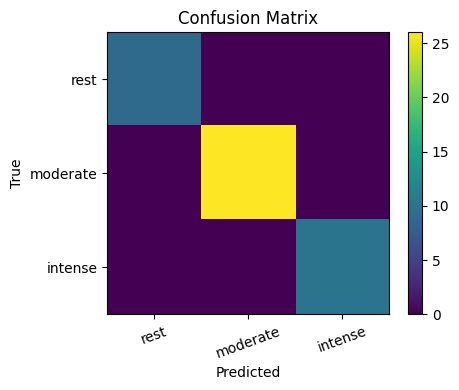

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], [LABEL_NAMES[i] for i in range(3)], rotation=20)
plt.yticks([0, 1, 2], [LABEL_NAMES[i] for i in range(3)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

15. Feature importance

emg_mav_synth    0.249293
emg_rms_synth    0.235833
emg_wl_synth     0.204308
temp_synth       0.175208
gyro_std         0.036213
acc_std          0.027212
hr_mean          0.023214
gyro_mean        0.020250
acc_mean         0.014708
acc_energy       0.011821
hr_std           0.001940
dtype: float64


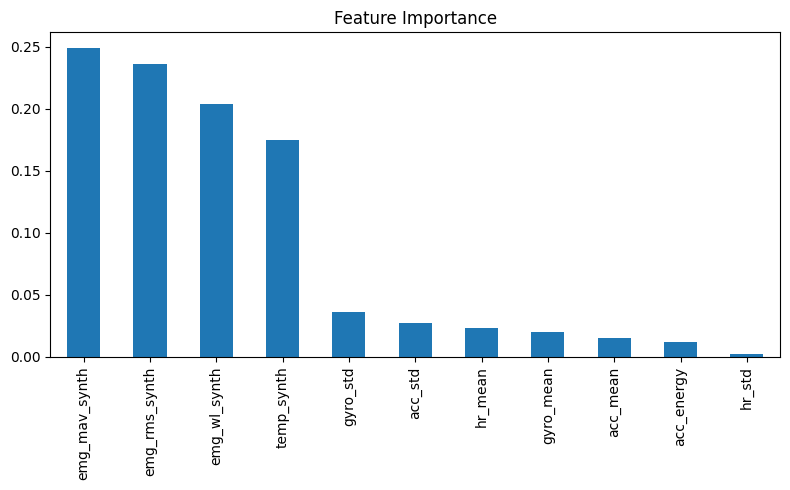

In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

16. Save model

In [16]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/activity_classifier_rf.pkl")
print("Model saved.")

Model saved.


17. Save processed features

In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

features_df.to_csv("../data/processed/activity_fusion_features.csv", index=False)
print("Features saved.")

Features saved.


# Conclusions

- Built a 3-class classifier for:
    rest / physical activity / intense physical activity

- Used real PAMAP2 IMU + HR features

- Added synthetic EMG + temperature features for temporary fusion

# This notebook can later be upgraded by replacing synthetic EMG/temp with real prototype sensor features